In [102]:
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from folium.plugins import Fullscreen

def plot_balance(df, class_column, title = "Distribuição das Classes"):
    class_counts = df[class_column].value_counts()
    plt.figure(figsize=(8, 8))
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            val = int(round(pct * total / 100.0))
            return f'{pct:.1f}%\n({val:,})'
        return my_autopct
    plt.pie(
        class_counts.values,
        labels=class_counts.index,
        autopct=make_autopct(class_counts.values),
        startangle=140,
        colors=plt.cm.Set2.colors,  # Paleta de cores suave
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

test_tile_path = "./dataset/test_tile/"
roi_tile_path = "./dataset/roi_tiles/"

In [104]:
test_tile_name = "tile_C51L41_WGS84"
test_tile = gpd.read_file(f"{test_tile_path}{test_tile_name}.gpkg")
if test_tile.crs != "EPSG:4326":
    test_tile = test_tile.to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = test_tile.total_bounds
center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
test_tile_id = test_tile.iloc[0]["id"]
test_tile_id

'C51L41'

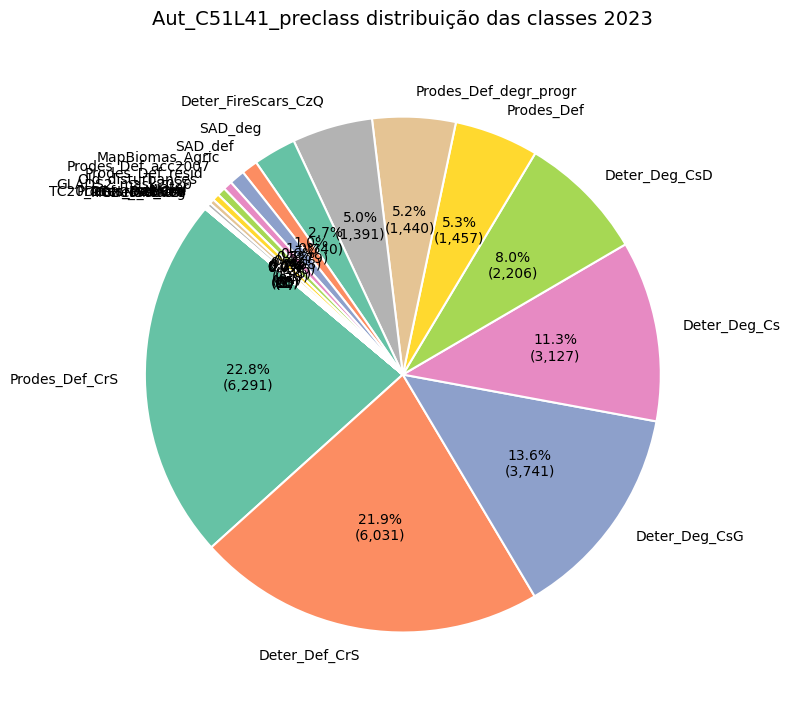

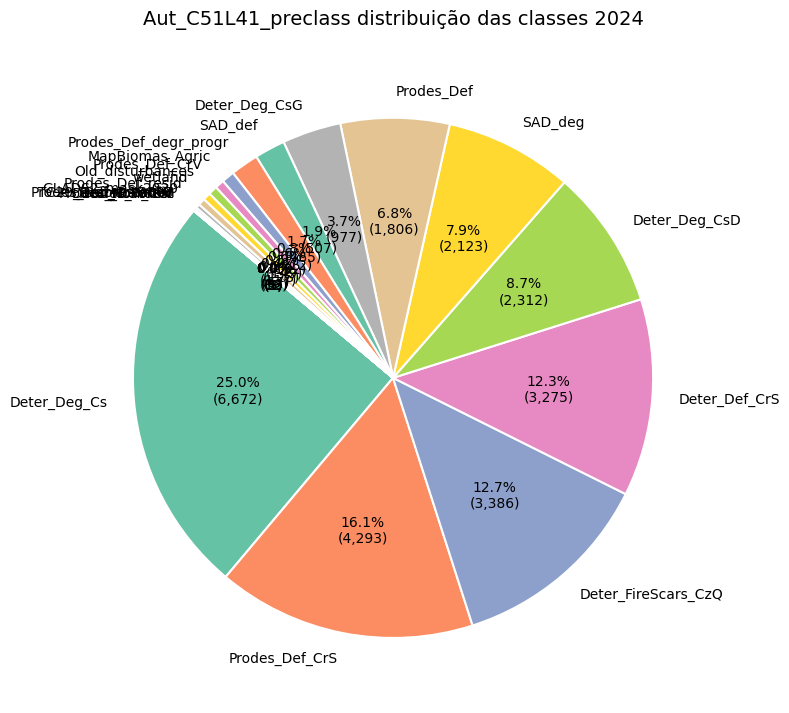

,doy_2020,date,idx,class_multisource,date_multisource,geometry
0,1,2020-01-01,1,Old_disturbances,2020-01-01,"POLYGON ((-61.1719 -8.2377, -61.1719 -8.2376, ..."
1,1,2020-01-01,2,Deter_Def_CrS,2023-08-17,"POLYGON ((-61.1609 -8.237, -61.1609 -8.2369, -..."
2,1,2020-01-01,3,Deter_Def_CrS,2021-03-26,"POLYGON ((-61.2117 -8.2266, -61.2117 -8.2265, ..."
3,1,2020-01-01,4,Deter_Def_CrS,2020-08-12,"POLYGON ((-61.1979 -8.2021, -61.1978 -8.2021, ..."
4,1,2020-01-01,5,Deter_Deg_Cs,2022-09-20,"POLYGON ((-61.1971 -8.187, -61.197 -8.187, -61..."


In [29]:
samples_test_name = "Aut_C51L41_preclass"
samples_test = gpd.read_file(f"{test_tile_path}{samples_test_name}.gpkg")

year = 2023
class_column = "class_multisource"
samples_test_2023 = samples_test[samples_test["date"].dt.year == year]

plot_balance(samples_test_2023, class_column, f"{samples_test_name} distribuição das classes {year}")

year = 2024
class_column = "class_multisource"
samples_test_2024 = samples_test[samples_test["date"].dt.year == year]

plot_balance(samples_test_2024, class_column, f"{samples_test_name} distribuição das classes {year}")

samples_test.head()

In [72]:
roi_tile_1_name = "tile_C51L34_Eco03_WGS84"
roi_tile_1 = gpd.read_file(f"{roi_tile_path}{roi_tile_1_name}.gpkg")
if roi_tile_1.crs != "EPSG:4326":
    roi_tile_1 = roi_tile_1.to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = roi_tile_1.total_bounds
roi_tile_1_id = roi_tile_1.iloc[0]["id"]
roi_tile_1_id

'C51L34'

In [90]:
roi_samples_tile_1_name = f"Aut_{roi_tile_1_id}_Eco03_CorteSeletivo_year"
roi_samples_tile_1 = gpd.read_file(f"{roi_tile_path}{roi_samples_tile_1_name}.gpkg")
roi_samples_tile_1["label"] = "Corte Seletivo"
roi_samples_tile_1 = roi_samples_tile_1[["year", "label", "geometry"]]
roi_samples_tile_1.head()

,year,label,geometry
0,2020,Corte Seletivo,"POLYGON ((-61.2218 -9.9988, -61.2218 -9.999, -..."
1,2020,Corte Seletivo,"POLYGON ((-61.2224 -9.9986, -61.2223 -9.9986, ..."
2,2020,Corte Seletivo,"POLYGON ((-61.2221 -9.9981, -61.2221 -9.998, -..."
3,2020,Corte Seletivo,"POLYGON ((-61.2222 -9.9979, -61.2221 -9.9979, ..."
4,2020,Corte Seletivo,"POLYGON ((-61.2317 -9.9978, -61.2317 -9.9976, ..."


In [77]:
roi_deter_tile_1_name = f"Deter20_24_{roi_tile_1_id}_Eco03_classdisturbios"
roi_deter_tile_1 = gpd.read_file(f"{roi_tile_path}{roi_deter_tile_1_name}.gpkg")
roi_deter_tile_1.head()

,id,i,CLASS,PATH_ROW,DATE,SENSOR,SATELLITE,YEAR,area_rel,AREA_FDAS,geometry
0,C51L34,4.0,CS_DESORDENADO,038017,2021-09-29,WFI,AMAZONIA-1,2021.0,98.557446,8.712427e+05,"MULTIPOLYGON (((-61.10038 -9.93365, -61.09923 ..."
1,C51L34,4.0,CS_DESORDENADO,038017,2021-09-29,WFI,AMAZONIA-1,2021.0,98.557446,1.497486e+05,"MULTIPOLYGON (((-61.00936 -9.97664, -61.00936 ..."
2,C51L34,4.0,CS_DESORDENADO,038017,2021-09-14,WFI,AMAZONIA-1,2021.0,98.557446,3.433100e+06,"MULTIPOLYGON (((-61.03085 -9.94431, -61.03085 ..."
3,C51L34,4.0,CS_DESORDENADO,038017,2021-09-14,WFI,AMAZONIA-1,2021.0,98.557446,8.124923e+06,"MULTIPOLYGON (((-61.01569 -9.95018, -61.01094 ..."
4,C51L34,4.0,CS_DESORDENADO,038017,2021-09-29,WFI,AMAZONIA-1,2021.0,98.557446,7.762325e+04,"MULTIPOLYGON (((-61.00883 -9.9374, -61.00551 -..."


In [69]:
roi_tile_2_name = "tile_C60L63_Eco01_WGS84"
roi_tile_2 = gpd.read_file(f"{roi_tile_path}{roi_tile_2_name}.gpkg")
if roi_tile_2.crs != "EPSG:4326":
    roi_tile_2 = roi_tile_2.to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = roi_tile_2.total_bounds
roi_tile_2_id = roi_tile_2.iloc[0]["id"]
roi_tile_2_id

'C60L63'

In [95]:
roi_samples_tile_2_name = f"Aut_{roi_tile_2_id}_Eco01_CorteSeletivo"
roi_samples_tile_2 = gpd.read_file(f"{roi_tile_path}{roi_samples_tile_2_name}.gpkg")
roi_samples_tile_2["year"] = [str(dt.year) for dt in roi_samples_tile_2["date"]]
roi_samples_tile_2["label"] = "Corte Seletivo"
roi_samples_tile_2 = roi_samples_tile_2.drop(columns = ["doy_2020", "date"])
roi_samples_tile_2 = roi_samples_tile_2[["year", "label", "geometry"]]
roi_samples_tile_2.head()

,year,label,geometry
0,2020,Corte Seletivo,"POLYGON ((-58.964 -2.6385, -58.964 -2.6387, -5..."
1,2020,Corte Seletivo,"POLYGON ((-58.7834 -2.5841, -58.7835 -2.5841, ..."
2,2020,Corte Seletivo,"POLYGON ((-58.8988 -2.5021, -58.8989 -2.5021, ..."
3,2020,Corte Seletivo,"POLYGON ((-58.8988 -2.502, -58.8987 -2.502, -5..."
4,2020,Corte Seletivo,"POLYGON ((-58.9641 -2.6386, -58.9641 -2.6387, ..."


In [48]:
roi_deter_tile_2_name = f"Deter20_24_{roi_tile_2_id}_Eco01_classdisturbios"
roi_deter_tile_2 = gpd.read_file(f"{roi_tile_path}{roi_deter_tile_2_name}.gpkg")
roi_deter_tile_2.head()

,id,i,CLASS,PATH_ROW,DATE,SENSOR,SATELLITE,YEAR,area_rel,AREA_FDAS,geometry
0,C60L63,8.0,CS_DESORDENADO,176105,2021-05-28,AWFI,CBERS-4,2021.0,99.898104,1.868791e+07,"MULTIPOLYGON (((-58.85085 -2.51414, -58.85085 ..."
1,C60L63,8.0,CS_DESORDENADO,037016,2021-08-03,WFI,AMAZONIA-1,2021.0,99.898104,1.602447e+06,"MULTIPOLYGON (((-58.87492 -2.53494, -58.87974 ..."
2,C60L63,8.0,CS_DESORDENADO,172105,2021-08-26,AWFI,CBERS-4,2021.0,99.898104,5.231818e+07,"MULTIPOLYGON (((-58.89273 -2.53985, -58.89296 ..."
3,C60L63,8.0,CS_DESORDENADO,169105,2022-08-08,AWFI,CBERS-4,2022.0,99.898104,2.067003e+06,"MULTIPOLYGON (((-58.85037 -2.50898, -58.85063 ..."
4,C60L63,8.0,CS_DESORDENADO,038015,2023-04-12,WFI,AMAZONIA-1,2023.0,99.898104,1.695936e+06,"MULTIPOLYGON (((-58.95684 -2.61791, -58.9572 -..."


In [105]:
# # 3. Cria o mapa interativo
# Map = folium.Map(location=center, zoom_start=12, tiles="OpenStreetMap")

# # 4. Adiciona a camada de satélite como base opcional
# folium.TileLayer(
#     tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
#     attr="Google Satellite",
#     name="Google Satellite"
# ).add_to(Map)

# # ============== Teste Tile ==============
# folium.GeoJson(
#     test_tile,
#     name=f"Test Tile {test_tile_id}",
#     style_function=lambda feature: {
#         "fillColor": "#ff7800",
#         "color": "#000000",       # Cor da borda
#         "weight": 2,              # Espessura da borda
#         "fillOpacity": 0.2,       # Transparência do preenchimento
#     },
#     tooltip=folium.GeoJsonTooltip(
#         fields=[col for col in tile.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
#         localize=True
#     )
# ).add_to(Map)

# year = 2024
# label = "Deter_Deg_CsG"
# label_column = "class_multisource"
# samples = samples_test[samples_test["date"].dt.year == year]
# samples = samples.drop(columns = ["date", "date_multisource"])
# samples = samples[samples[label_column] == label]
# folium.GeoJson(
#     samples,
#     name=f"Test Samples Distúrbios {label} {year}",
#     style_function=lambda feature: {
#         "fillColor": "#ff7800",
#         "color": "#000000",       # Cor da borda
#         "weight": 2,              # Espessura da borda
#         "fillOpacity": 0.2,       # Transparência do preenchimento
#     },
#     tooltip=folium.GeoJsonTooltip(
#         fields=[col for col in samples.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
#         localize=True
#     )
# ).add_to(Map)

# # ============== ROI 1 Tile ==============
# folium.GeoJson(
#     roi_tile_1,
#     name=f"ROI 1 Tile {roi_tile_1_id}",
#     style_function=lambda feature: {
#         "fillColor": "#ff7800",
#         "color": "#000000",       # Cor da borda
#         "weight": 2,              # Espessura da borda
#         "fillOpacity": 0.2,       # Transparência do preenchimento
#     },
#     tooltip=folium.GeoJsonTooltip(
#         fields=[col for col in tile.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
#         localize=True
#     )
# ).add_to(Map)

# label = "Corte Seletivo"
# samples = roi_samples_tile_1[roi_samples_tile_1["year"] == str(year)]
# samples = samples.drop(columns = ["year"])
# folium.GeoJson(
#     samples,
#     name=f"ROI 1 Samples Distúrbios {label} {year}",
#     style_function=lambda feature: {
#         "fillColor": "#ff7800",
#         "color": "#000000",       # Cor da borda
#         "weight": 2,              # Espessura da borda
#         "fillOpacity": 0.2,       # Transparência do preenchimento
#     },
#     tooltip=folium.GeoJsonTooltip(
#         fields=[col for col in samples.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
#         localize=True
#     )
# ).add_to(Map)

# # ============== ROI 2 Tile ==============
# folium.GeoJson(
#     roi_tile_2,
#     name=f"ROI 2 Tile {roi_tile_2_id}",
#     style_function=lambda feature: {
#         "fillColor": "#ff7800",
#         "color": "#000000",       # Cor da borda
#         "weight": 2,              # Espessura da borda
#         "fillOpacity": 0.2,       # Transparência do preenchimento
#     },
#     tooltip=folium.GeoJsonTooltip(
#         fields=[col for col in tile.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
#         localize=True
#     )
# ).add_to(Map)

# label = "Corte Seletivo"
# samples = roi_samples_tile_2[roi_samples_tile_2["year"] == str(year)]
# samples = samples.drop(columns = ["year"])
# folium.GeoJson(
#     samples,
#     name=f"ROI 2 Samples Distúrbios {label} {year}",
#     style_function=lambda feature: {
#         "fillColor": "#ff7800",
#         "color": "#000000",       # Cor da borda
#         "weight": 2,              # Espessura da borda
#         "fillOpacity": 0.2,       # Transparência do preenchimento
#     },
#     tooltip=folium.GeoJsonTooltip(
#         fields=[col for col in samples.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
#         localize=True
#     )
# ).add_to(Map)

# Fullscreen(
#     position="topright",
#     title="Expand me",
#     title_cancel="Exit me",
#     force_separate_button=True,
# ).add_to(Map)

# folium.LayerControl().add_to(Map)

# Map